# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [169]:
train = pd.read_csv('Teen_Mental_Health_Dataset.csv')
train.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Exploratory Data Analysis

In [170]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [171]:
d = train.describe()
d

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


Text(0.5, 1.0, 'Distribusi Depression Label')

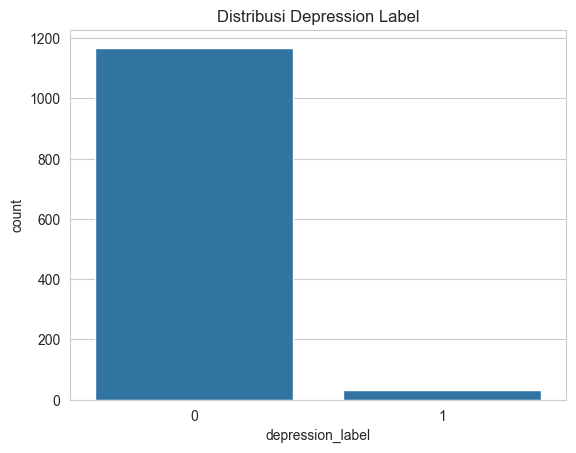

In [172]:
sns.countplot(x='depression_label', data=train)
plt.title("Distribusi Depression Label")

<Axes: xlabel='depression_label', ylabel='count'>

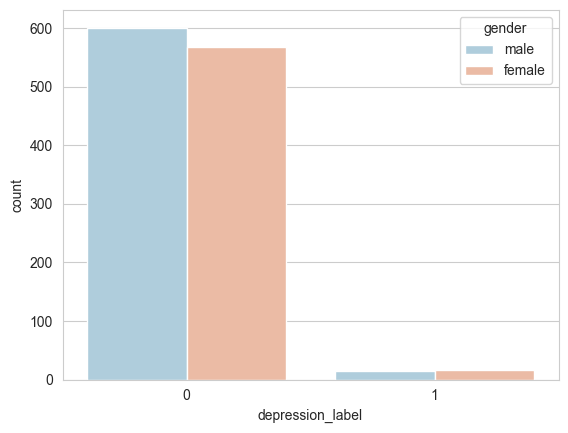

In [173]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='depression_label', hue='gender', data=train, palette='RdBu_r')

<Axes: xlabel='depression_label', ylabel='count'>

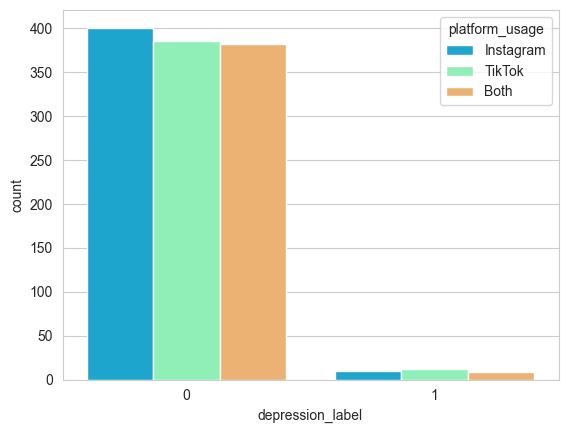

In [174]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.set_style('whitegrid')
sns.countplot(x='depression_label',
              hue='platform_usage',
              data=train,
              palette='rainbow')

Text(0.5, 1.0, 'Persentase Depresi berdasarkan Platform Usage')

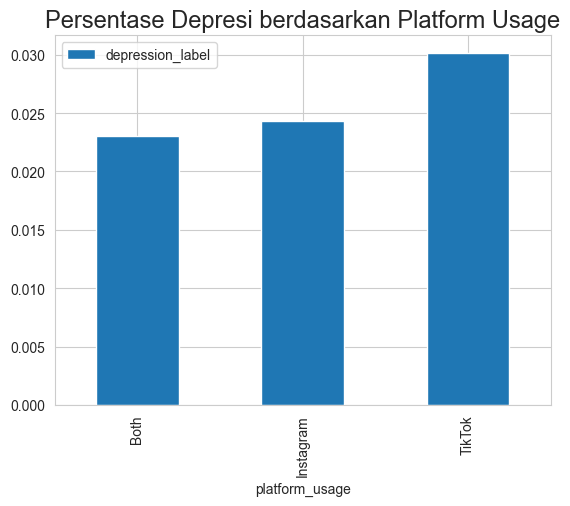

In [175]:
f_class_survived = train.groupby('platform_usage')['depression_label'].mean()
f_class_survived = pd.DataFrame(f_class_survived)

f_class_survived
f_class_survived.plot.bar(y='depression_label')

plt.title("Persentase Depresi berdasarkan Platform Usage", fontsize=17)

<Axes: xlabel='depression_label', ylabel='count'>

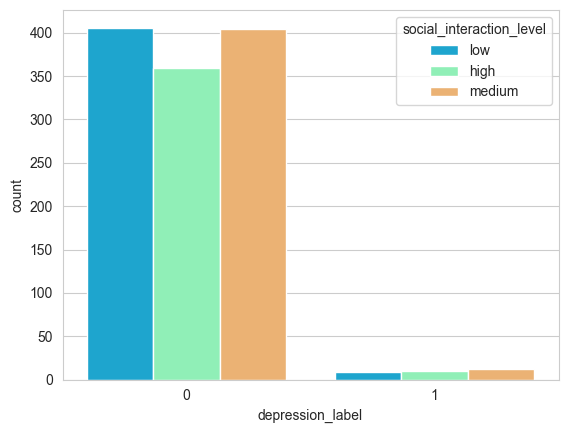

In [176]:
# Survived vs Sibling and Spouses
sns.set_style('whitegrid')
sns.countplot(x='depression_label',
              hue='social_interaction_level',
              data=train,
              palette='rainbow')

<Axes: title={'center': 'Histogram Usia Remaja'}, xlabel='Usia', ylabel='Count'>

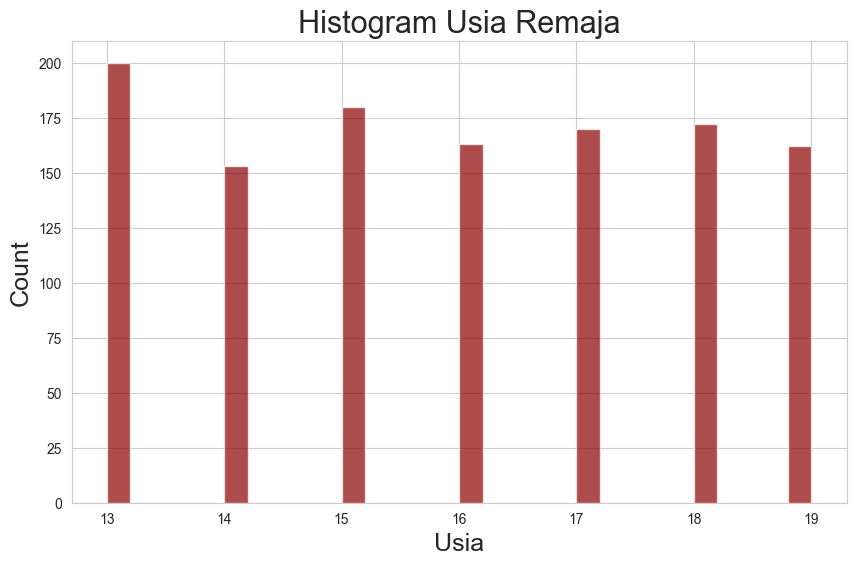

In [177]:
plt.xlabel("Usia",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram Usia Remaja",fontsize=22)

train['age'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10,6))

C:\Users\User\AppData\Local\Temp\ipykernel_18800\1436205413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage',


<Axes: xlabel='Platform Usage', ylabel='Age'>

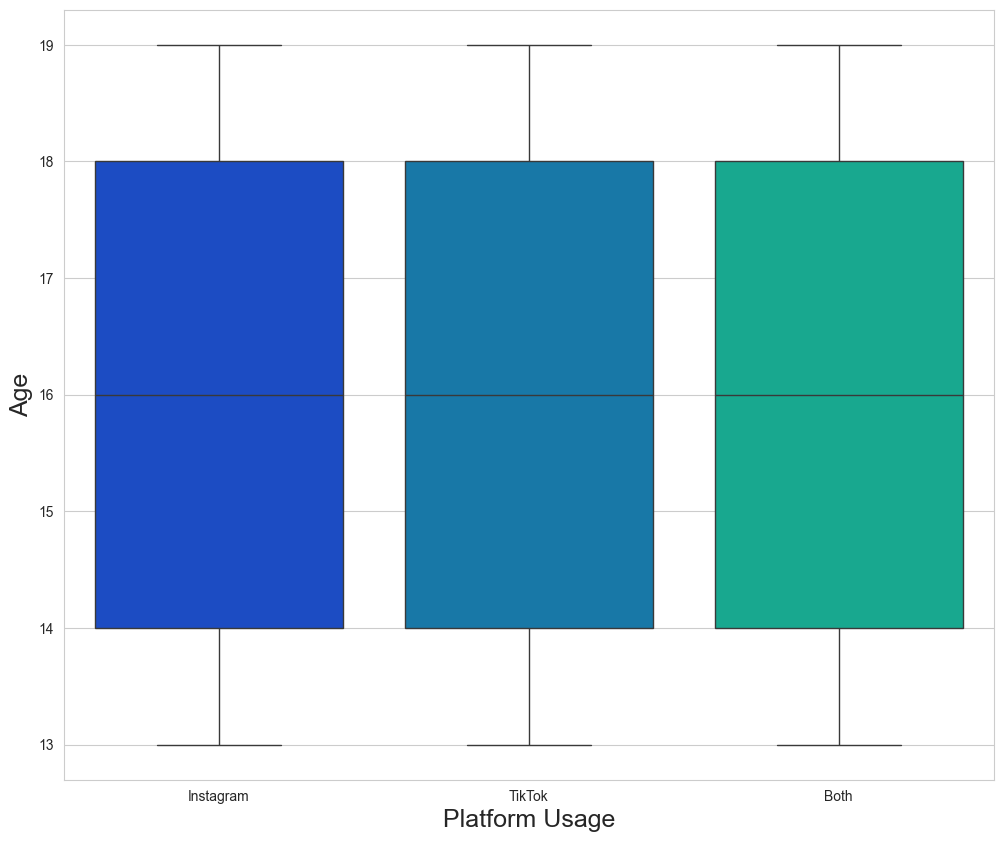

In [178]:
plt.figure(figsize=(12, 10))
plt.xlabel("Platform Usage", fontsize=18)
plt.ylabel("Age", fontsize=18)

sns.boxplot(x='platform_usage',
            y='age',
            data=train,
            palette='winter')

# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [180]:
train = pd.read_csv('Teen_Mental_Health_Dataset.csv')
train.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### Exploratory Data Analysis

In [181]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [182]:
d = train.describe()
d

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


Text(0, 0.5, 'Jumlah')

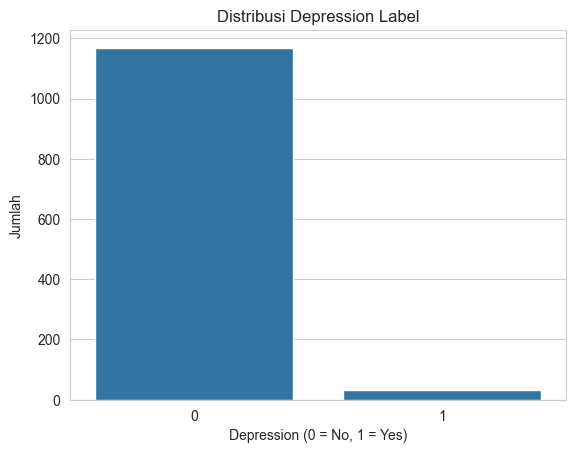

In [183]:
sns.countplot(x='depression_label', data=train)
plt.title("Distribusi Depression Label")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Jumlah")

<Axes: xlabel='depression_label', ylabel='count'>

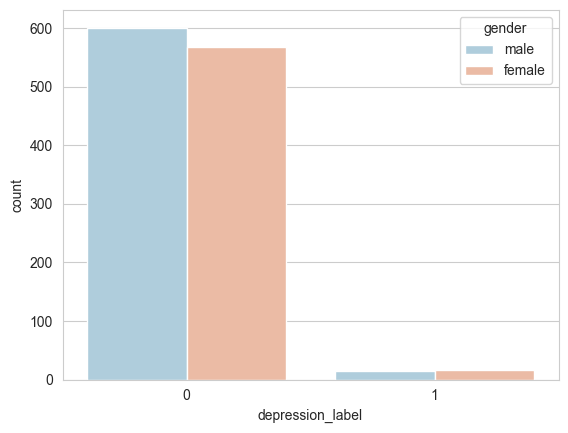

In [184]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='depression_label', hue='gender', data=train, palette='RdBu_r')

<Axes: xlabel='depression_label', ylabel='count'>

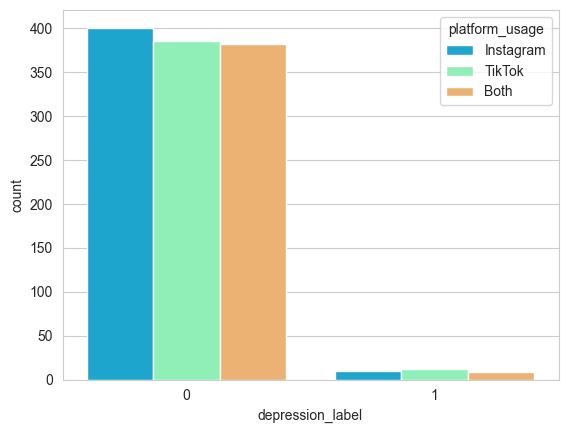

In [185]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.set_style('whitegrid')
sns.countplot(x='depression_label',
              hue='platform_usage',
              data=train,
              palette='rainbow')

Text(0.5, 1.0, 'Persentase Depresi berdasarkan Platform Usage')

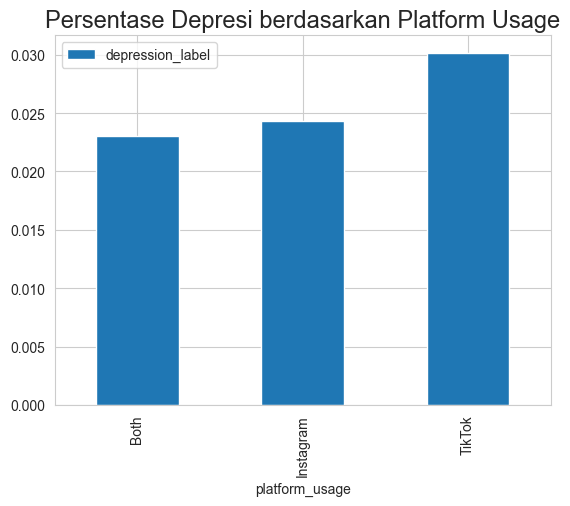

In [186]:
f_class_survived = train.groupby('platform_usage')['depression_label'].mean()
f_class_survived = pd.DataFrame(f_class_survived)

f_class_survived
f_class_survived.plot.bar(y='depression_label')

plt.title("Persentase Depresi berdasarkan Platform Usage", fontsize=17)

Text(0.5, 1.0, 'Depression berdasarkan Social Interaction Level')

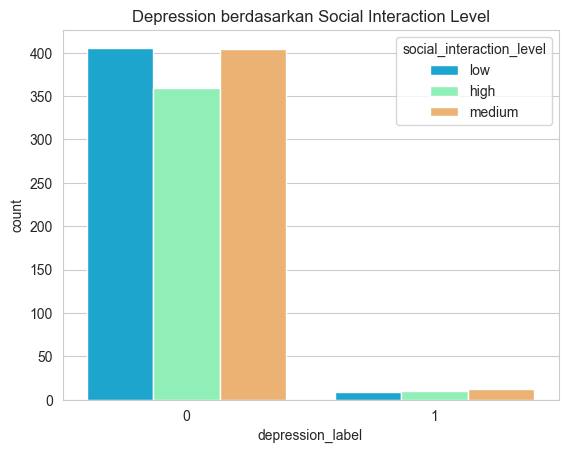

In [187]:
# Depression vs Social Interaction
sns.set_style('whitegrid')
sns.countplot(x='depression_label',
              hue='social_interaction_level',
              data=train,
              palette='rainbow')

plt.title("Depression berdasarkan Social Interaction Level")

<Axes: title={'center': 'Histogram Usia Remaja'}, xlabel='Usia', ylabel='Count'>

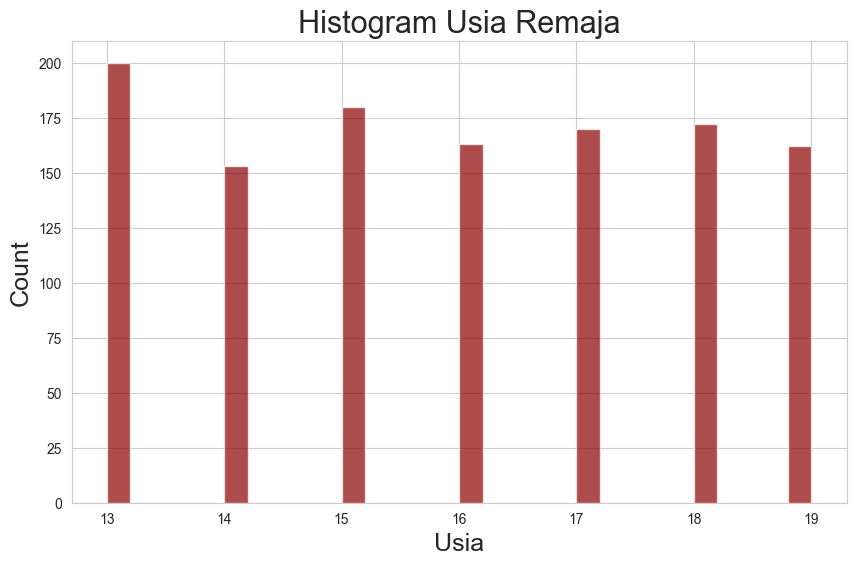

In [188]:
plt.xlabel("Usia",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram Usia Remaja",fontsize=22)

train['age'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10,6))

C:\Users\User\AppData\Local\Temp\ipykernel_18800\3208803500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage',


<Axes: xlabel='Platform Usage', ylabel='Age'>

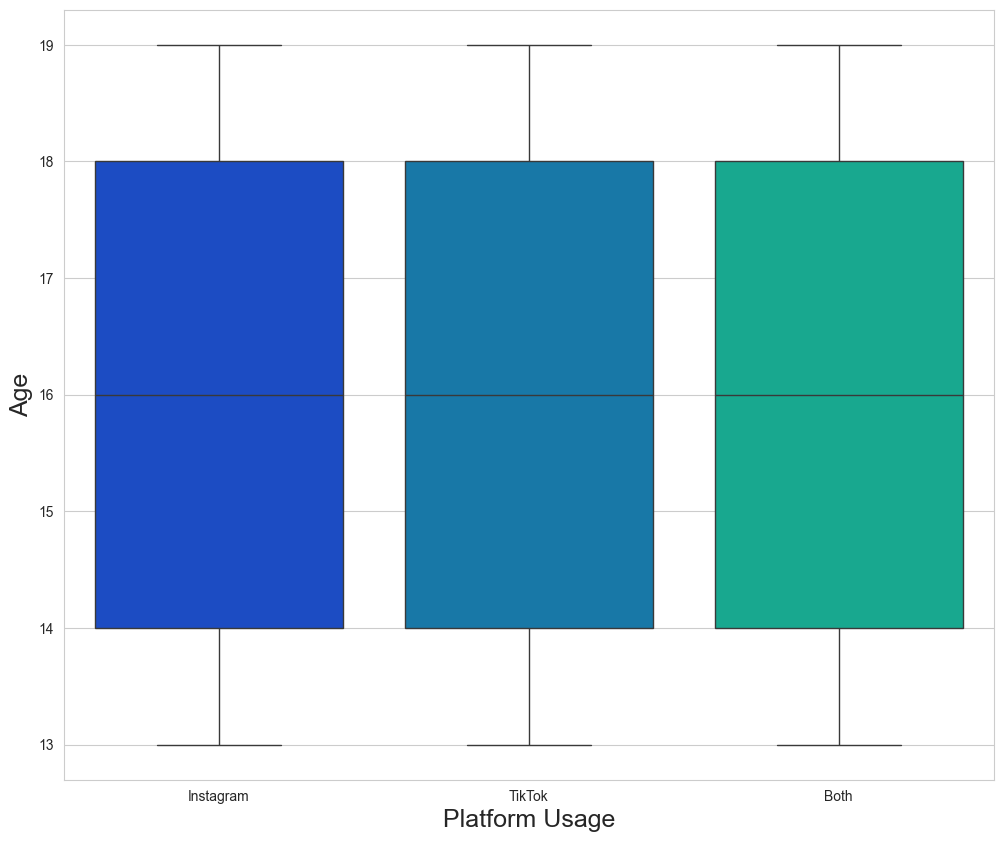

In [189]:
# Distribusi umur berdasarkan platform usage
plt.figure(figsize=(12, 10))
plt.xlabel("Platform Usage", fontsize=18)
plt.ylabel("Age", fontsize=18)

sns.boxplot(x='platform_usage',
            y='age',
            data=train,
            palette='winter')

Text(0.5, 0, 'Platform Usage')

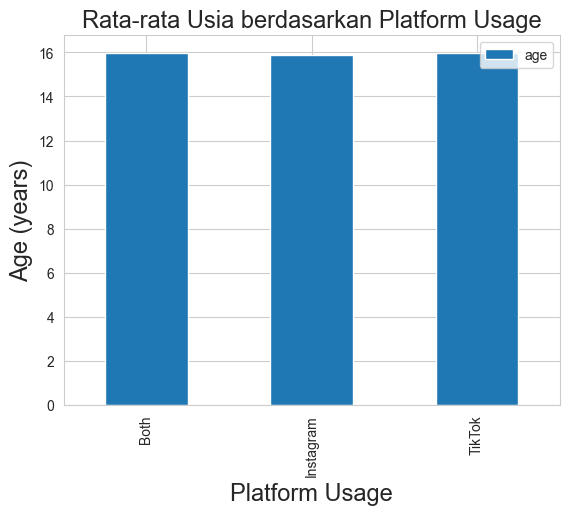

In [190]:
f_class_Age = train.groupby('platform_usage')['age'].mean()
f_class_Age = pd.DataFrame(f_class_Age)

f_class_Age.plot.bar(y='age')

plt.title("Rata-rata Usia berdasarkan Platform Usage", fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Platform Usage", fontsize=17)

### Fitur Engineering

In [191]:
print("Missing Value:")
print(train.isnull().sum())

Missing Value:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [192]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['gender'] = le.fit_transform(train['gender'])
train['platform_usage'] = le.fit_transform(train['platform_usage'])
train['social_interaction_level'] = le.fit_transform(train['social_interaction_level'])

In [193]:
print("\nData setelah encoding:")
print(train.head())


Data setelah encoding:
   age  gender  daily_social_media_hours  platform_usage  sleep_hours  \
0   14       1                       7.9               1          7.4   
1   19       0                       1.9               2          8.0   
2   17       0                       1.3               1          7.6   
3   15       1                       7.4               2          6.9   
4   15       0                       4.7               0          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

   social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                         1

In [194]:
print("\nTipe Data:")
print(train.dtypes)


Tipe Data:
age                           int64
gender                        int64
daily_social_media_hours    float64
platform_usage                int64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [195]:
X = train.drop('depression_label', axis=1)
y = train['depression_label']

In [196]:
print("\nShape fitur:", X.shape)
print("Shape target:", y.shape)


Shape fitur: (1200, 12)
Shape target: (1200,)


### Training

In [197]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [198]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (840, 12)
Test shape: (360, 12)


# **KNN**

In [199]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model KNN
clf1 = KNeighborsClassifier(n_neighbors=5)

# Training
clf1.fit(X_train_scaled, y_train)

# Prediksi
y_pred = clf1.predict(X_test_scaled)

### Evaluation

In [200]:
# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model KNN: {accuracy:.2f}')

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.97

Confusion Matrix:
[[350   1]
 [  9   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       351
           1       0.00      0.00      0.00         9

    accuracy                           0.97       360
   macro avg       0.49      0.50      0.49       360
weighted avg       0.95      0.97      0.96       360



# **Naive Bayes**

In [201]:
from sklearn.naive_bayes import GaussianNB

# Model Naive Bayes
nb = GaussianNB()

# Training
nb.fit(X_train_scaled, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test_scaled)

### Evaluation

In [202]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.99

Confusion Matrix:
[[351   0]
 [  3   6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       351
           1       1.00      0.67      0.80         9

    accuracy                           0.99       360
   macro avg       1.00      0.83      0.90       360
weighted avg       0.99      0.99      0.99       360



Text(50.722222222222214, 0.5, 'Actual')

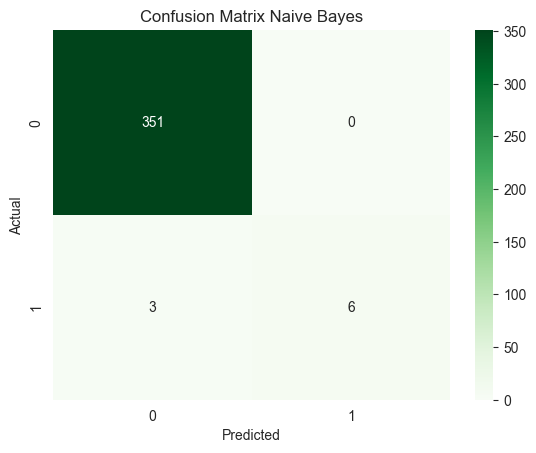

In [203]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# **Decision Tree**

In [204]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model
dt = DecisionTreeClassifier(random_state=42)

# Training
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [205]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 1.00

Confusion Matrix:
[[351   0]
 [  1   8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      0.89      0.94         9

    accuracy                           1.00       360
   macro avg       1.00      0.94      0.97       360
weighted avg       1.00      1.00      1.00       360



Text(50.722222222222214, 0.5, 'Actual')

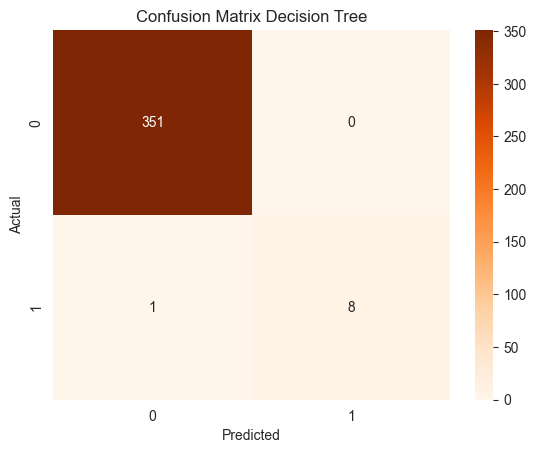

In [206]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [207]:
# copy struktur data training
new_data = X_train.iloc[[0]].copy()

# isi hanya kolom yang ada di dataset kamu
if 'age' in new_data.columns:
    new_data['age'] = 16

if 'gender' in new_data.columns:
    new_data['gender'] = 1

if 'screen_time_hours' in new_data.columns:
    new_data['screen_time_hours'] = 6.5

if 'sleep_hours' in new_data.columns:
    new_data['sleep_hours'] = 6.0

if 'physical_activity_hours' in new_data.columns:
    new_data['physical_activity_hours'] = 1.0

if 'platform_usage' in new_data.columns:
    new_data['platform_usage'] = 2

if 'social_interaction_level' in new_data.columns:
    new_data['social_interaction_level'] = 0

In [208]:
new_data_scaled = scaler.transform(new_data)

new_prediction = nb.predict(new_data_scaled)
print("Prediksi Depresi (0=Tidak, 1=Ya):", new_prediction[0])

proba = nb.predict_proba(new_data_scaled)
print("Probabilitas:", proba[0])

Prediksi Depresi (0=Tidak, 1=Ya): 0
Probabilitas: [1.00000000e+00 1.08187288e-17]


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [209]:
from sklearn.neighbors import KNeighborsClassifier

clf2 = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

clf2.fit(X_train_scaled, y_train)

y_pred_knn = clf2.predict(X_test_scaled)

In [210]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.97
Confusion Matrix:
[[349   2]
 [  8   1]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       351
           1       0.33      0.11      0.17         9

    accuracy                           0.97       360
   macro avg       0.66      0.55      0.58       360
weighted avg       0.96      0.97      0.97       360



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [211]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.986905   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.986905   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.980952   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.980952   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.979762   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.979762   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.979762   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.979762   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.977381   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.977381   
4   {'metric': 'euclidean', 'n_neighbors

In [212]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [213]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [214]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.98
Presisi:  0.77
Recall:   0.77
F1-Score: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       351
           1       0.56      0.56      0.56         9

    accuracy                           0.98       360
   macro avg       0.77      0.77      0.77       360
weighted avg       0.98      0.98      0.98       360

Confusion Matrix:
[[347   4]
 [  4   5]]


In [215]:
import pandas as pd

# ambil struktur kolom dari training
new_data_1 = X_train.iloc[[0]].copy()

# isi nilai sesuai Teen Mental Health
if 'age' in new_data_1.columns:
    new_data_1['age'] = 16

if 'gender' in new_data_1.columns:
    new_data_1['gender'] = 1

if 'screen_time_hours' in new_data_1.columns:
    new_data_1['screen_time_hours'] = 6.5

if 'sleep_hours' in new_data_1.columns:
    new_data_1['sleep_hours'] = 6.0

if 'physical_activity_hours' in new_data_1.columns:
    new_data_1['physical_activity_hours'] = 1.0

if 'platform_usage' in new_data_1.columns:
    new_data_1['platform_usage'] = 2

if 'social_interaction_level' in new_data_1.columns:
    new_data_1['social_interaction_level'] = 0

# prediksi
prediction = best_model.predict(new_data_1)

print("Prediksi Depresi (0 = Tidak, 1 = Ya):", prediction[0])

Prediksi Depresi (0 = Tidak, 1 = Ya): 0


Text(0.5, 0, 'Social Interaction Level')

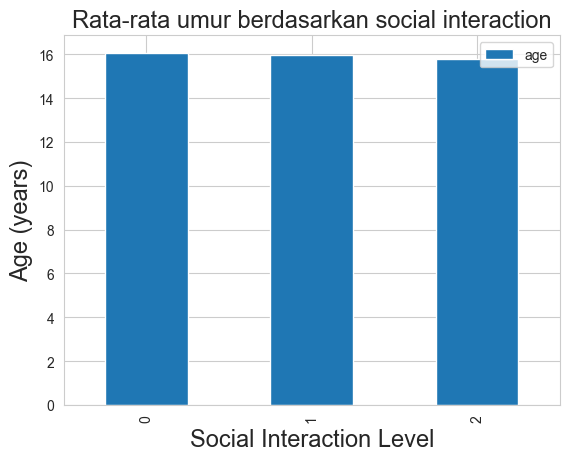

In [216]:
f_class_Age = train.groupby('social_interaction_level')['age'].mean()
f_class_Age = pd.DataFrame(f_class_Age)

f_class_Age.plot.bar(y='age')

plt.title("Rata-rata umur berdasarkan social interaction", fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Social Interaction Level", fontsize=17)

### Fitur Engineering

In [217]:
for col in train.columns:
    print(col)

age
gender
daily_social_media_hours
platform_usage
sleep_hours
screen_time_before_sleep
academic_performance
physical_activity
social_interaction_level
stress_level
anxiety_level
addiction_level
depression_label


In [218]:
train.columns = train.columns.str.strip()
train.columns = train.columns.str.lower()
train.columns = train.columns.str.replace(" ", "_")
train.columns = train.columns.str.replace("(", "")
train.columns = train.columns.str.replace(")", "")
train.columns = train.columns.str.replace("/", "_")

In [219]:
train.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [220]:
train['age'] = train['age'].fillna(train['age'].mean())
train['daily_social_media_hours'] = train['daily_social_media_hours'].fillna(train['daily_social_media_hours'].mean())
train['sleep_hours'] = train['sleep_hours'].fillna(train['sleep_hours'].mean())
train['screen_time_before_sleep'] = train['screen_time_before_sleep'].fillna(train['screen_time_before_sleep'].mean())
train['academic_performance'] = train['academic_performance'].fillna(train['academic_performance'].mean())
train['physical_activity'] = train['physical_activity'].fillna(train['physical_activity'].mean())
train['stress_level'] = train['stress_level'].fillna(train['stress_level'].mean())
train['anxiety_level'] = train['anxiety_level'].fillna(train['anxiety_level'].mean())
train['addiction_level'] = train['addiction_level'].fillna(train['addiction_level'].mean())

In [221]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['gender'] = le.fit_transform(train['gender'])
train['platform_usage'] = le.fit_transform(train['platform_usage'])
train['social_interaction_level'] = le.fit_transform(train['social_interaction_level'])

In [222]:
X = train.drop('depression_label', axis=1)
y = train['depression_label']

In [223]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [224]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train.drop('depression_label', axis=1),
    train['depression_label'],
    test_size=0.30,
    random_state=42
)

In [226]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (840, 12)
Test : (360, 12)


# **KNN**

In [227]:
from sklearn.neighbors import KNeighborsClassifier

clf1 = KNeighborsClassifier()
clf1.fit(X_train, y_train)

y_pred = clf1.predict(X_test)

In [228]:
y_pred = clf1.predict(X_test)

### Evaluation

In [229]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.98
Confusion Matrix:
[[349   2]
 [  5   4]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       351
           1       0.67      0.44      0.53         9

    accuracy                           0.98       360
   macro avg       0.83      0.72      0.76       360
weighted avg       0.98      0.98      0.98       360



# **Naive Bayes**

In [230]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [231]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.99
Confusion Matrix:
[[351   0]
 [  3   6]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       351
           1       1.00      0.67      0.80         9

    accuracy                           0.99       360
   macro avg       1.00      0.83      0.90       360
weighted avg       0.99      0.99      0.99       360



# **Decision Tree**

In [232]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [233]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 1.00
Confusion Matrix:
[[351   0]
 [  1   8]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      0.89      0.94         9

    accuracy                           1.00       360
   macro avg       1.00      0.94      0.97       360
weighted avg       1.00      1.00      1.00       360



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [234]:
import pandas as pd

# Data baru sesuai dataset Teen Mental Health
new_data = pd.DataFrame([{
    'age': 17,
    'gender': 1,
    'daily_social_media_hours': 6,
    'platform_usage': 2,
    'sleep_hours': 5.5,
    'screen_time_before_sleep': 2,
    'academic_performance': 70,
    'physical_activity': 1,
    'social_interaction_level': 1,
    'stress_level': 8,
    'anxiety_level': 7,
    'addiction_level': 6
}])

In [235]:
new_prediction = nb.predict(new_data)

print("Prediksi Depresi (0=Tidak, 1=Ya):", new_prediction[0])

proba = nb.predict_proba(new_data)
print("Probabilitas [Tidak Depresi, Depresi]:", proba[0])

Prediksi Depresi (0=Tidak, 1=Ya): 0
Probabilitas [Tidak Depresi, Depresi]: [1. 0.]


# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [236]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [237]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.98
Confusion Matrix:
[[349   2]
 [  5   4]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       351
           1       0.67      0.44      0.53         9

    accuracy                           0.98       360
   macro avg       0.83      0.72      0.76       360
weighted avg       0.98      0.98      0.98       360



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [238]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.986905   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.986905   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.980952   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.980952   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.979762   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.979762   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.979762   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.979762   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.977381   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.977381   
4   {'metric': 'euclidean', 'n_neighbors

In [239]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [240]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [241]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.98
Presisi:  0.77
Recall:   0.77
F1-Score: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       351
           1       0.56      0.56      0.56         9

    accuracy                           0.98       360
   macro avg       0.77      0.77      0.77       360
weighted avg       0.98      0.98      0.98       360

Confusion Matrix:
[[347   4]
 [  4   5]]


In [242]:
import pandas as pd

new_data_1 = pd.DataFrame([{
    'age': 17,
    'gender': 1,
    'daily_social_media_hours': 6,
    'platform_usage': 2,
    'sleep_hours': 5.5,
    'screen_time_before_sleep': 2,
    'academic_performance': 70,
    'physical_activity': 1,
    'social_interaction_level': 1,
    'stress_level': 8,
    'anxiety_level': 7,
    'addiction_level': 6
}])

In [243]:
prediction = best_model.predict(new_data_1)

print("Prediksi Depresi (0=Tidak, 1=Ya):", prediction[0])

Prediksi Depresi (0=Tidak, 1=Ya): 0
